In [1]:
import pandas as pd
import joblib

from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
import shap

# Processing Data

In [2]:
def process_data(filename, /):

  if not isinstance(filename, str):

    raise TypeError

  df = pd.read_excel(filename)

  df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors = "coerce")

  df.dropna(inplace = True)

  df.drop_duplicates(inplace = True)

  df.drop("customerID", axis = 1, inplace = True)

  df["gender"] = df["gender"].apply(lambda x: 1 if x == "Female" else 0)

  yes_no_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]

  df[yes_no_cols] = df[yes_no_cols].map(lambda x: 1 if x == "Yes" else 0)

  cols_to_encode = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
                    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
                    "Contract", "PaymentMethod"]

  encoder = OrdinalEncoder(categories=[
    ["No phone service", "No", "Yes"],           # MultipleLines
    ["No", "DSL", "Fiber optic"],                # InternetService
    ["No internet service", "No", "Yes"],        # OnlineSecurity
    ["No internet service", "No", "Yes"],        # OnlineBackup
    ["No internet service", "No", "Yes"],        # DeviceProtection
    ["No internet service", "No", "Yes"],        # TechSupport
    ["No internet service", "No", "Yes"],        # StreamingTV
    ["No internet service", "No", "Yes"],        # StreamingMovies
    ["Month-to-month", "One year", "Two year"],  # Contract
    ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"]])

  df[cols_to_encode] = encoder.fit_transform(df[cols_to_encode])

  scaler = MinMaxScaler()

  feature_cols = df.drop(["Churn"] + cols_to_encode, axis = 1).columns

  df[feature_cols] = scaler.fit_transform(df[feature_cols])

  return df

In [3]:
file_name = "CustomerChurn_data.xlsx"

df = process_data(file_name)
print(df.head())

   gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
0     1.0            0.0      1.0         0.0  0.000000           0.0   
1     0.0            0.0      0.0         0.0  0.464789           1.0   
2     0.0            0.0      0.0         0.0  0.014085           1.0   
3     0.0            0.0      0.0         0.0  0.619718           0.0   
4     1.0            0.0      0.0         0.0  0.014085           1.0   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0            0.0              1.0             1.0           2.0   
1            1.0              1.0             2.0           1.0   
2            1.0              1.0             2.0           2.0   
3            0.0              1.0             2.0           1.0   
4            1.0              2.0             1.0           1.0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0               1.0          1.0          1.0              1.0       0.0   
1     

# Model Predictions

In [4]:
y_target = df["Churn"]
X_data = df.drop("Churn", axis = 1)

In [5]:
model = joblib.load("XGB_model.joblib")

preds = model.predict_proba(X_data)

print(preds)
print(len(preds))

[[0.1569804  0.8430196 ]
 [0.94004977 0.05995026]
 [0.3414334  0.6585666 ]
 ...
 [0.64005196 0.35994804]
 [0.17272347 0.8272765 ]
 [0.6903489  0.30965108]]
7032


# SHAP Values

(7032, 19)


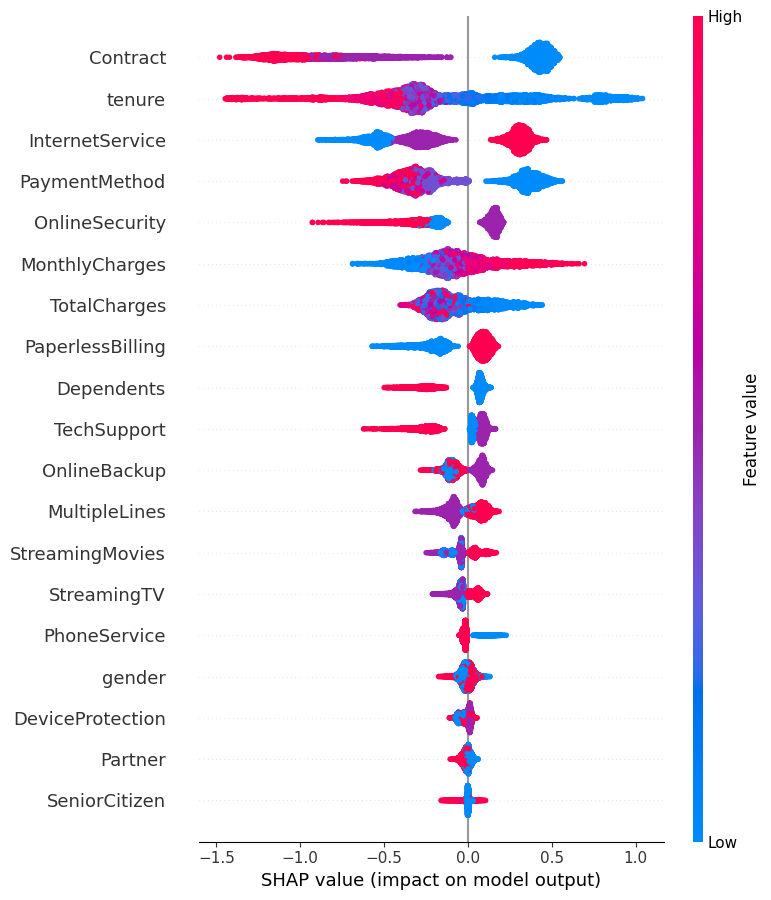

In [6]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_data)

print(shap_values.shape)

shap_df = pd.DataFrame(shap_values, columns = X_data.columns)

shap.summary_plot(shap_values, X_data)

In [7]:
df_churn = pd.read_excel(file_name)

df_churn["TotalCharges"] = pd.to_numeric(df_churn["TotalCharges"], errors = "coerce")

df_churn.dropna(inplace = True)

df_churn.drop_duplicates(inplace = True)

df_churn = df_churn.reset_index(drop = True)

print(df_churn.info())
print("\n", df_churn.iloc[0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [8]:
shap_summary = ""

for i in range(len(X_data)):

    shap_series = shap_df.iloc[i]

    top_features = shap_series.abs().sort_values(ascending = False).head(5)

    for feature in top_features.index:

        value = shap_series[feature]

        shap_summary += f"{feature}: {value:.3f}\n"

    df_churn.loc[i, "SHAP values"]= shap_summary

    shap_summary = ""

In [9]:
print(df_churn["SHAP values"].iloc[0])

tenure: 0.706
Contract: 0.495
PaymentMethod: 0.368
InternetService: -0.234
OnlineBackup: -0.164



In [10]:
df_churn["ModelPrediction"] = (preds[:, 1] * 100).astype(float).round(2)
print(df_churn["ModelPrediction"])

0       84.30
1        6.00
2       65.86
3        6.10
4       83.63
        ...  
7027     9.98
7028    11.85
7029    35.99
7030    82.73
7031    30.97
Name: ModelPrediction, Length: 7032, dtype: float64


# Summary Column

In [11]:
def summarise_data(customer):

  pronoun = "She" if customer["gender"] == "Female" else "He"


  summary = (f'Customer {customer["customerID"]} is a {"female" if customer["gender"] == "Female" else "male"} '
  f'who is {"not" if customer["SeniorCitizen"] == 0 else ""} a senior citizen. '
  f'{pronoun} {"has" if customer["Partner"] == "Yes" else "does not have"} a partner or dependents. '
  f'{pronoun} has been with the company for {customer["tenure"]} month(s).\n'
  f'The customer {"does not have" if customer["PhoneService"] == "No" else "has"} phone service and{" therefore" if customer["PhoneService"] == "No" else ""} '
  f'{"uses" if customer["MultipleLines"] == "Yes" else "does not use"} multiple lines.\n'
  )

  summary += (f'{pronoun} {"does not have" if customer["InternetService"] == "No" else "uses " + customer["InternetService"]} internet service.\n'
  f'Online security is {"enabled" if customer["OnlineSecurity"] == "Yes" else "not enabled"}, '
  f'and online backup is {"enabled" if customer["OnlineBackup"] == "Yes" else "not enabled"}. '
  f'Device protection is {"enabled" if customer["DeviceProtection"] == "Yes" else "not enabled"}, '
  f'and tech support is {"enabled" if customer["TechSupport"] == "Yes" else "not enabled"}.\n'
  f'Streaming TV is {"enabled" if customer["StreamingTV"] == "Yes" else "not enabled"}, '
  f'and streaming movies is {"enabled" if customer["StreamingMovies"] == "Yes" else "not enabled"}.\n'

  )

  summary += (f'The customer is on a {customer["Contract"]} contract and {"uses" if customer["PaperlessBilling"] == "Yes" else "does not use"} paperless billing.\n'
      f'{"Her" if pronoun == "She" else "His"} payment method is {customer["PaymentMethod"]}. '
      f'{"Her" if pronoun == "She" else "His"} monthly charge is {customer["MonthlyCharges"]} dollars and total charges so far are {customer["TotalCharges"]} dollars.\n'
      f'\nThe model predicted that this customer will churn with a probability of {customer["ModelPrediction"]}%.\n'
      f'\nTop Contributing factors (SHAP):\n {customer["SHAP values"]}'
  )

  return summary

In [12]:
df_churn["Summary"] = df_churn.apply(summarise_data, axis = 1)

print(df_churn.iloc[0])
print(df_churn["Summary"].iloc[0])

customerID                                                 7590-VHVEG
gender                                                         Female
SeniorCitizen                                                       0
Partner                                                           Yes
Dependents                                                         No
tenure                                                              1
PhoneService                                                       No
MultipleLines                                        No phone service
InternetService                                                   DSL
OnlineSecurity                                                     No
OnlineBackup                                                      Yes
DeviceProtection                                                   No
TechSupport                                                        No
StreamingTV                                                        No
StreamingMovies     

In [13]:
df_churn.to_excel("CustomerChurn_processed.xlsx", index = False)